==================== FOIL : FIRST ORDER INDUCTIVE LEARNER ====================

Constants (8) : Alice, Bob, Carol, David, AI, ML, DBMS, Networks
Total possible TakesCourseTaughtBy(x,y) pairs : 64
Positive examples : 5  -> [('Bob', 'Alice'), ('Bob', 'Carol'), ('Carol', 'Alice'), ('David', 'Alice'), ('David', 'David')]
Negative examples : 59

BACKGROUND KNOWLEDGE BASE
+-------------+-----------------+
| Predicate   | Arguments       |
+=============+=================+
| Teaches     | Alice, AI       |
+-------------+-----------------+
| Teaches     | Alice, ML       |
+-------------+-----------------+
| Teaches     | Carol, DBMS     |
+-------------+-----------------+
| Teaches     | David, Networks |
+-------------+-----------------+
| Enrolled    | Bob, AI         |
+-------------+-----------------+
| Enrolled    | Bob, DBMS       |
+-------------+-----------------+
| Enrolled    | Carol, ML       |
+-------------+-----------------+
| Enrolled    | David, AI       |
+-------------+----

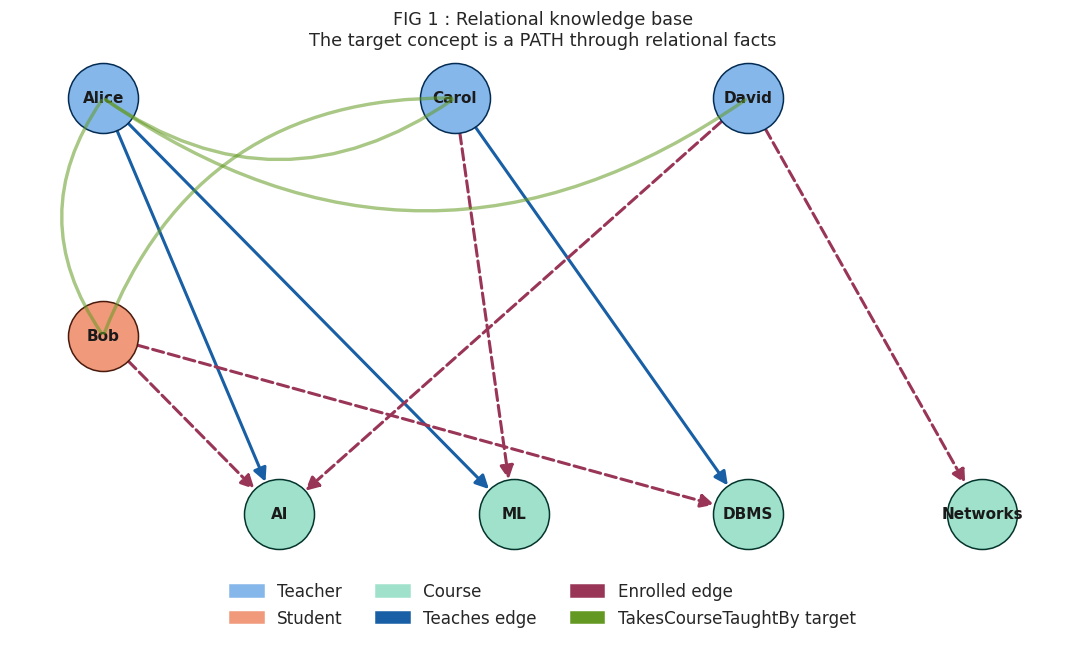

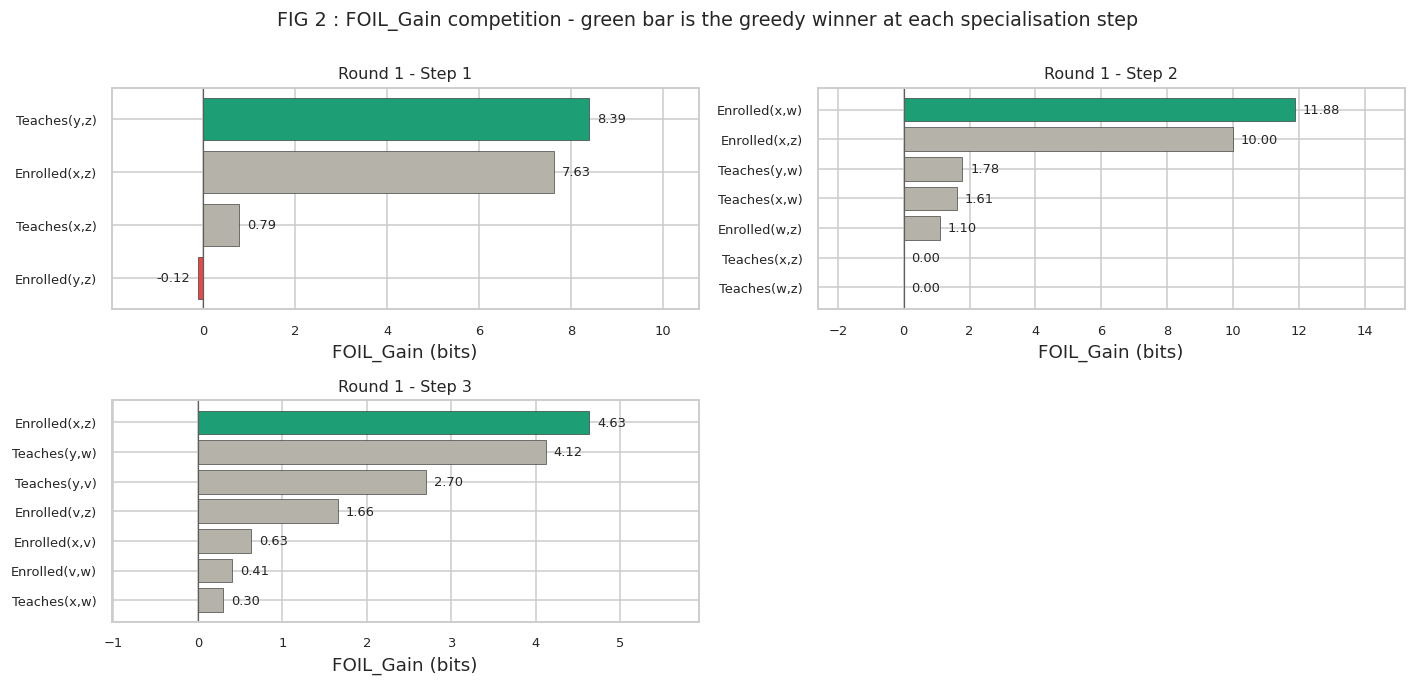

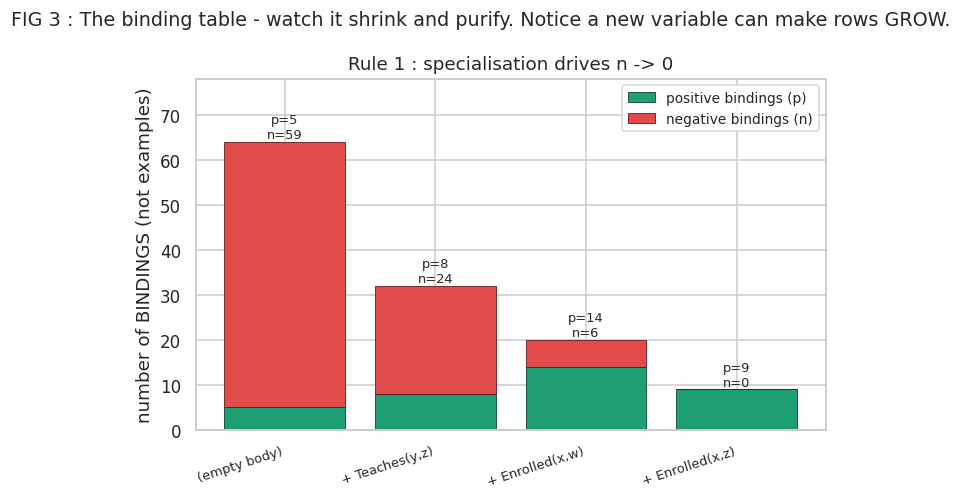

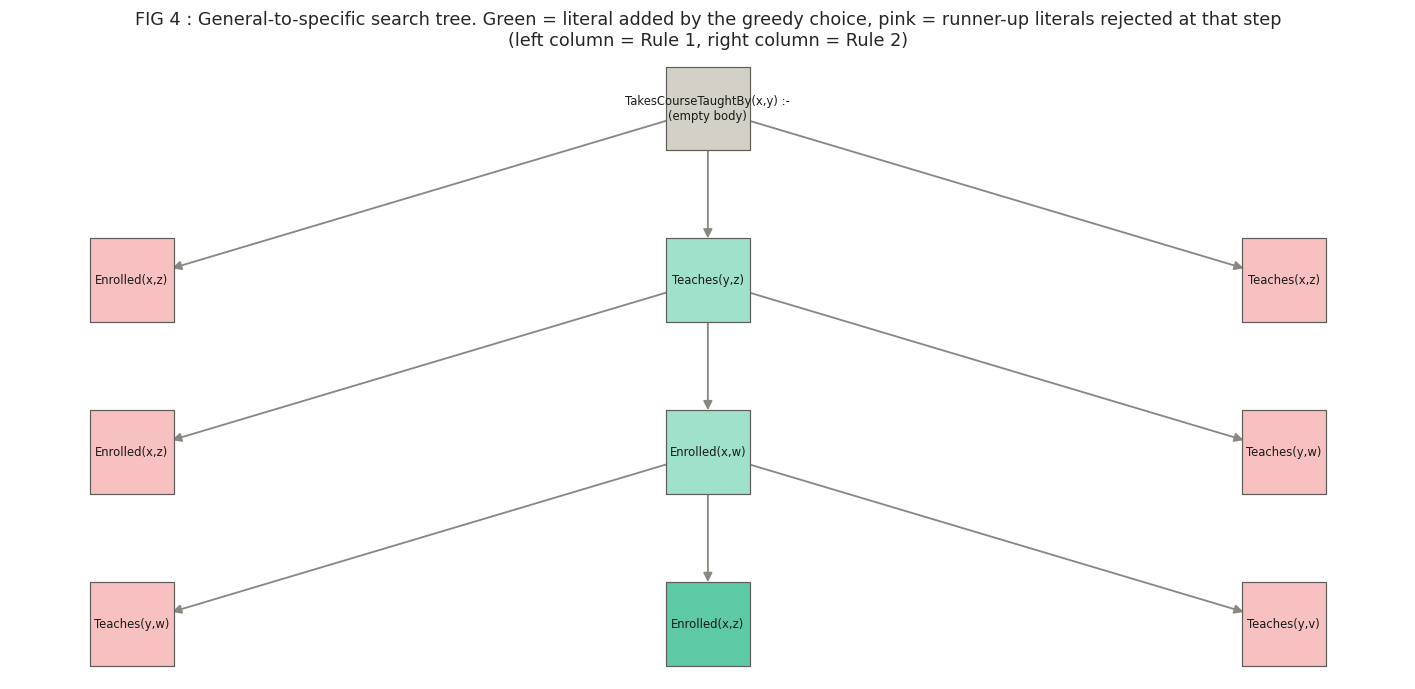

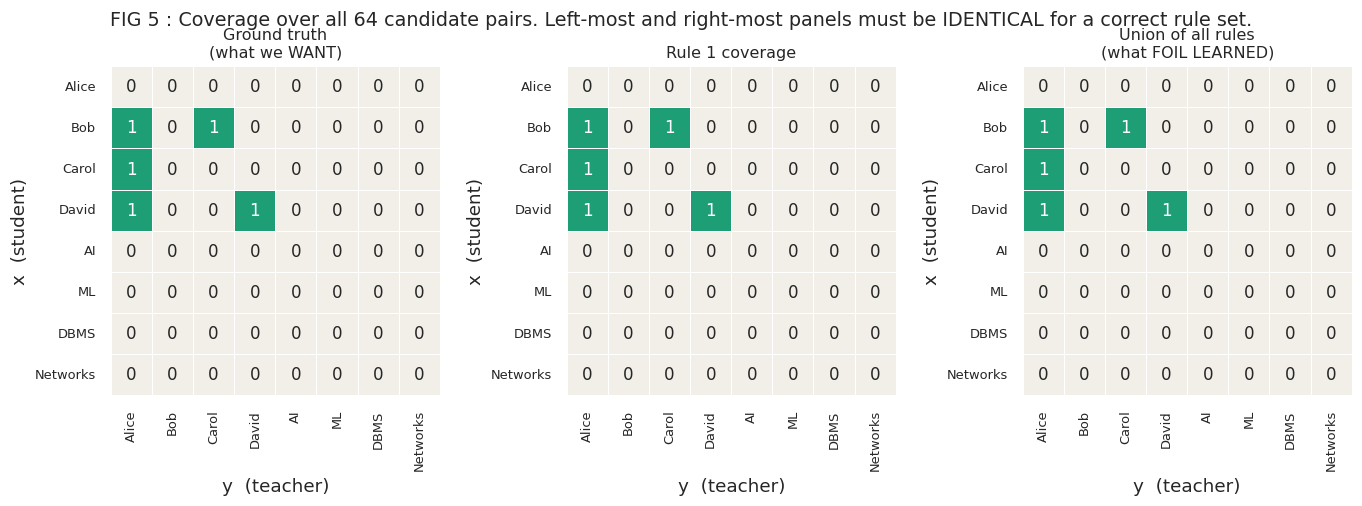

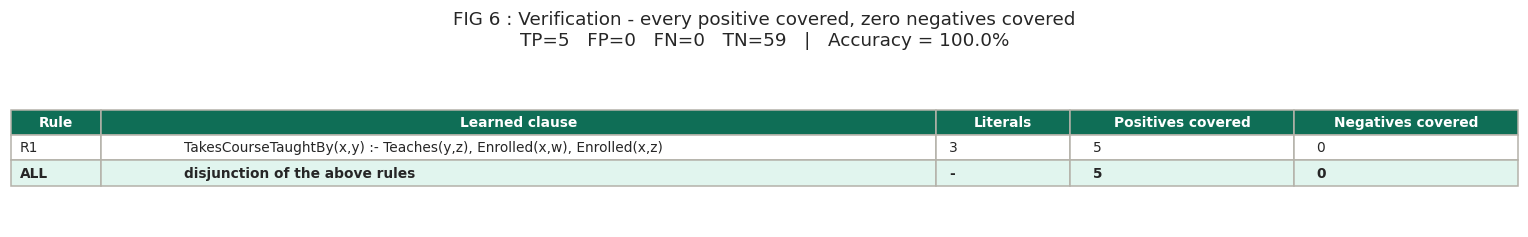


=========================== ROUND-BY-ROUND SUMMARY ===========================
+---------+------------------------------------------------------------------------+------------+-----------+--------------------+-----------+-----------+
|   round | rule                                                                   |   literals |   covered |   remaining_before |   final_p |   final_n |
+=========+========================================================================+============+===========+====================+===========+===========+
|       1 | TakesCourseTaughtBy(x,y) :- Teaches(y,z), Enrolled(x,w), Enrolled(x,z) |          3 |         5 |                  5 |         9 |         0 |
+---------+------------------------------------------------------------------------+------------+-----------+--------------------+-----------+-----------+

CONFUSION MATRIX over all 64 pairs
+-----------------+-----------------+-----------------+
|                 |   Predicted POS |   Predicted NEG

In [37]:
!pip install -q networkx matplotlib seaborn pandas tabulate

import math
import itertools
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import seaborn as sns

from tabulate import tabulate
from matplotlib.patches import Patch

sns.set_theme(style="whitegrid")

plt.rcParams["figure.dpi"] = 110
plt.rcParams["font.size"] = 11


# ============================================================================
# SECTION 1 : THE KNOWLEDGE BASE
# ============================================================================

CONSTANTS = [
    "Alice", "Bob", "Carol", "David",
    "AI", "ML", "DBMS", "Networks"
]

FACTS = {
    "Teaches": {
        ("Alice", "AI"),
        ("Alice", "ML"),
        ("Carol", "DBMS"),
        ("David", "Networks")
    },

    "Enrolled": {
        ("Bob", "AI"),
        ("Bob", "DBMS"),
        ("Carol", "ML"),
        ("David", "AI"),
        ("David", "Networks")
    }
}

ARITY = {
    "Teaches": 2,
    "Enrolled": 2
}

TARGET = "TakesCourseTaughtBy"
TARGET_VARS = ("x", "y")


def is_true(pred, args):
    return tuple(args) in FACTS[pred]


def ground_truth(x, y):
    return any(
        (x, course) in FACTS["Enrolled"]
        and
        (y, course) in FACTS["Teaches"]
        for course in CONSTANTS
    )


ALL_PAIRS = [
    (a, b)
    for a in CONSTANTS
    for b in CONSTANTS
]

POSITIVES = [
    p
    for p in ALL_PAIRS
    if ground_truth(*p)
]

NEGATIVES = [
    p
    for p in ALL_PAIRS
    if not ground_truth(*p)
]


print("=" * 78)
print(
    " FOIL : FIRST ORDER INDUCTIVE LEARNER ".center(
        78,
        "="
    )
)
print("=" * 78)

print(
    "\nConstants (%d) : %s"
    % (
        len(CONSTANTS),
        ", ".join(CONSTANTS)
    )
)

print(
    "Total possible %s(x,y) pairs : %d"
    % (
        TARGET,
        len(ALL_PAIRS)
    )
)

print(
    "Positive examples : %d  -> %s"
    % (
        len(POSITIVES),
        POSITIVES
    )
)

print(
    "Negative examples : %d"
    % len(NEGATIVES)
)


kb_rows = []

for pred in ["Teaches", "Enrolled"]:
    for fact in sorted(FACTS[pred]):
        kb_rows.append([
            pred,
            ", ".join(fact)
        ])

print("\nBACKGROUND KNOWLEDGE BASE")

print(
    tabulate(
        kb_rows,
        headers=["Predicate", "Arguments"],
        tablefmt="grid"
    )
)


# ============================================================================
# SECTION 2 : LITERALS, BINDINGS AND RULE EVALUATION
# ============================================================================

def lit_str(lit):
    neg, pred, vs = lit

    return (
        ("not " if neg else "")
        +
        "%s(%s)"
        % (
            pred,
            ",".join(vs)
        )
    )


def rule_str(body):

    head = "%s(%s)" % (
        TARGET,
        ",".join(TARGET_VARS)
    )

    if not body:
        return head + " :- "

    return (
        head
        +
        " :- "
        +
        ", ".join(
            lit_str(l)
            for l in body
        )
    )


def extend_bindings(bindings, lit):

    neg, pred, vs = lit

    new_bindings = []
    parents = []

    for i, b in enumerate(bindings):

        if neg:

            args = tuple(
                b[v]
                for v in vs
            )

            if not is_true(pred, args):

                new_bindings.append(
                    dict(b)
                )

                parents.append(i)

        else:

            for fact in FACTS[pred]:

                nb = dict(b)

                ok = True

                for var, val in zip(vs, fact):

                    if var in nb:

                        if nb[var] != val:
                            ok = False
                            break

                    else:

                        nb[var] = val

                if ok:

                    new_bindings.append(nb)
                    parents.append(i)

    return new_bindings, parents


def split_bindings(bindings, pos_set):

    pos_idx = []
    neg_idx = []

    for i, b in enumerate(bindings):

        pair = (
            b["x"],
            b["y"]
        )

        if pair in pos_set:
            pos_idx.append(i)
        else:
            neg_idx.append(i)

    return pos_idx, neg_idx


def evaluate_rule(body, pairs):

    covered = set()

    for x, y in pairs:

        bindings = [
            {
                "x": x,
                "y": y
            }
        ]

        for lit in body:

            bindings, _ = extend_bindings(
                bindings,
                lit
            )

            if not bindings:
                break

        if bindings:
            covered.add(
                (x, y)
            )

    return covered


# ============================================================================
# SECTION 3 : CANDIDATE LITERAL GENERATION
# ============================================================================

NEW_VAR_POOL = [
    "z",
    "w",
    "v"
]

ENFORCE_LINKAGE = True
USE_NEGATION = False


def candidate_literals(body):

    used = set(TARGET_VARS)

    for _, _, vs in body:
        used.update(vs)

    candidates = []

    pool = sorted(used)

    if len(pool) < len(NEW_VAR_POOL) + len(used):

        for fresh in NEW_VAR_POOL:

            if fresh not in used:
                pool.append(fresh)
                break

    for pred in ARITY:

        arity = ARITY[pred]

        for combo in itertools.product(
            pool,
            repeat=arity
        ):

            combo = tuple(combo)

            if len(set(combo)) == 0:
                continue

            new_vars = [
                v
                for v in set(combo)
                if v not in used
            ]

            if len(new_vars) > 1:
                continue

            if ENFORCE_LINKAGE and body:

                if not any(
                    v in used
                    for v in combo
                ):
                    continue

            lit = (
                False,
                pred,
                combo
            )

            candidates.append(lit)

            if USE_NEGATION:

                candidates.append(
                    (
                        True,
                        pred,
                        combo
                    )
                )

    unique = {}

    for lit in candidates:
        unique[lit_str(lit)] = lit

    return [
        unique[k]
        for k in sorted(unique)
    ]


def n_new_vars(lit, body):

    used = set(TARGET_VARS)

    for _, _, vs in body:
        used.update(vs)

    return len([
        v
        for v in set(lit[2])
        if v not in used
    ])


# ============================================================================
# SECTION 4 : FOIL_GAIN
# ============================================================================

def foil_gain(p0, n0, p1, n1, t):

    if p1 == 0 or p0 == 0 or t == 0:
        return float("-inf")

    return t * (
        math.log2(
            p1 / (p1 + n1)
        )
        -
        math.log2(
            p0 / (p0 + n0)
        )
    )


# ============================================================================
# SECTION 5 : LEARN-ONE-RULE + SEQUENTIAL COVERING
# ============================================================================

TRACE = []
RULES = []
ROUND_LOG = []


def learn_one_rule(
    pos,
    neg,
    round_no
):

    pos_set = set(pos)

    universe = (
        list(pos)
        +
        list(neg)
    )

    body = []

    bindings = [
        {
            "x": a,
            "y": b
        }
        for a, b in universe
    ]

    pos_idx, neg_idx = split_bindings(
        bindings,
        pos_set
    )

    p0 = len(pos_idx)
    n0 = len(neg_idx)

    step = 0

    while n0 > 0 and step < 6:

        step += 1

        scored = []

        for lit in candidate_literals(body):

            nb, parents = extend_bindings(
                bindings,
                lit
            )

            npos, nneg = split_bindings(
                nb,
                pos_set
            )

            p1 = len(npos)
            n1 = len(nneg)

            surviving_parents = {
                parents[i]
                for i in npos
            }

            t = len(
                surviving_parents
                &
                set(pos_idx)
            )

            g = foil_gain(
                p0,
                n0,
                p1,
                n1,
                t
            )

            scored.append(
                dict(
                    round=round_no,
                    step=step,
                    literal=lit_str(lit),
                    p1=p1,
                    n1=n1,
                    t=t,
                    gain=g,
                    newvars=n_new_vars(
                        lit,
                        body
                    )
                )
            )

        scored.sort(
            key=lambda d: (
                -d["gain"],
                d["newvars"],
                d["literal"]
            )
        )

        TRACE.extend(scored)

        best = scored[0]

        if best["gain"] == float("-inf"):
            break

        best_lit = next(
            l
            for l in candidate_literals(body)
            if lit_str(l) == best["literal"]
        )

        print(
            "\n  Step %d : rule before -> %s   (p=%d, n=%d)"
            % (
                step,
                rule_str(body),
                p0,
                n0
            )
        )

        valid_scores = [
            s
            for s in scored
            if s["gain"] > float("-inf")
        ]

        top = pd.DataFrame(
            valid_scores
        )[
            [
                "literal",
                "p1",
                "n1",
                "t",
                "gain"
            ]
        ].head(6)

        top["gain"] = top["gain"].round(3)

        print(
            tabulate(
                top,
                headers=[
                    "candidate literal",
                    "p1",
                    "n1",
                    "t",
                    "FOIL_Gain"
                ],
                tablefmt="simple",
                showindex=False
            )
        )

        print(
            "  --> CHOSEN : %s"
            % best["literal"]
        )

        body.append(best_lit)

        bindings, _ = extend_bindings(
            bindings,
            best_lit
        )

        pos_idx, neg_idx = split_bindings(
            bindings,
            pos_set
        )

        p0 = len(pos_idx)
        n0 = len(neg_idx)

    return body, p0, n0


def foil(
    positives,
    negatives
):

    remaining = list(positives)

    round_no = 0

    while remaining:

        round_no += 1

        print(
            "\n" + "=" * 78
        )

        print(
            " OUTER LOOP ROUND %d : %d positive example(s) still uncovered"
            % (
                round_no,
                len(remaining)
            )
        )

        print(
            "=" * 78
        )

        body, p_end, n_end = learn_one_rule(
            remaining,
            negatives,
            round_no
        )

        covered = (
            evaluate_rule(
                body,
                ALL_PAIRS
            )
            &
            set(remaining)
        )

        if not covered:

            print(
                "  ! rule covers nothing new - stopping to avoid infinite loop"
            )

            break

        RULES.append(body)

        ROUND_LOG.append(
            dict(
                round=round_no,
                rule=rule_str(body),
                literals=len(body),
                covered=len(covered),
                remaining_before=len(remaining),
                final_p=p_end,
                final_n=n_end
            )
        )

        print(
            "\n  LEARNED RULE %d : %s"
            % (
                round_no,
                rule_str(body)
            )
        )

        print(
            "  Covers positives : %s"
            % sorted(covered)
        )

        remaining = [
            p
            for p in remaining
            if p not in covered
        ]

    return RULES


foil(
    POSITIVES,
    NEGATIVES
)


print(
    "\n" + "=" * 78
)

print(
    " FINAL LEARNED RULE SET ".center(
        78,
        "="
    )
)

print(
    "=" * 78
)

for i, r in enumerate(
    RULES,
    1
):

    print(
        "  R%d : %s"
        % (
            i,
            rule_str(r)
        )
    )


trace_df = pd.DataFrame(
    TRACE
)

trace_df = trace_df[
    trace_df.gain > float("-inf")
].reset_index(
    drop=True
)


# ============================================================================
# SECTION 6 : VISUAL ANALYSIS
# ============================================================================


# ---------------------------------------------------------------------------
# FIGURE 1 : RELATIONAL KNOWLEDGE BASE
# ---------------------------------------------------------------------------

G = nx.DiGraph()

G.add_nodes_from(
    CONSTANTS
)

for a, b in FACTS["Teaches"]:

    G.add_edge(
        a,
        b,
        rel="Teaches"
    )

for a, b in FACTS["Enrolled"]:

    G.add_edge(
        a,
        b,
        rel="Enrolled"
    )


pos_layout = {
    "Alice": (-1.5, 2),
    "Carol": (1.5, 2),
    "David": (4, 2),
    "Bob": (-1.5, 0),

    "AI": (0, -1.5),
    "ML": (2, -1.5),
    "DBMS": (4, -1.5),
    "Networks": (6, -1.5)
}


fig, ax = plt.subplots(
    figsize=(10, 6)
)


teacher_nodes = [
    "Alice",
    "Carol",
    "David"
]

student_nodes = [
    "Bob"
]

course_nodes = [
    "AI",
    "ML",
    "DBMS",
    "Networks"
]


nx.draw_networkx_nodes(
    G,
    pos_layout,
    nodelist=teacher_nodes,
    node_color="#85B7EB",
    node_size=2100,
    edgecolors="#042C53",
    ax=ax
)

nx.draw_networkx_nodes(
    G,
    pos_layout,
    nodelist=student_nodes,
    node_color="#F0997B",
    node_size=2100,
    edgecolors="#4A1B0C",
    ax=ax
)

nx.draw_networkx_nodes(
    G,
    pos_layout,
    nodelist=course_nodes,
    node_color="#9FE1CB",
    node_size=2100,
    edgecolors="#04342C",
    ax=ax
)


nx.draw_networkx_labels(
    G,
    pos_layout,
    font_size=10,
    font_weight="bold",
    ax=ax
)


teaches_edges = [
    (a, b)
    for a, b, d in G.edges(
        data=True
    )
    if d["rel"] == "Teaches"
]

enrolled_edges = [
    (a, b)
    for a, b, d in G.edges(
        data=True
    )
    if d["rel"] == "Enrolled"
]


nx.draw_networkx_edges(
    G,
    pos_layout,
    edgelist=teaches_edges,
    edge_color="#185FA5",
    width=2,
    arrowsize=18,
    node_size=2100,
    ax=ax
)

nx.draw_networkx_edges(
    G,
    pos_layout,
    edgelist=enrolled_edges,
    edge_color="#993556",
    width=2,
    style="dashed",
    arrowsize=18,
    node_size=2100,
    ax=ax
)


for a, b in POSITIVES:

    if a in pos_layout and b in pos_layout:

        ax.annotate(
            "",
            xy=pos_layout[a],
            xytext=pos_layout[b],
            arrowprops=dict(
                arrowstyle="-",
                color="#639922",
                lw=2.2,
                alpha=0.55,
                connectionstyle="arc3,rad=0.35"
            )
        )


ax.legend(
    handles=[
        Patch(
            color="#85B7EB",
            label="Teacher"
        ),
        Patch(
            color="#F0997B",
            label="Student"
        ),
        Patch(
            color="#9FE1CB",
            label="Course"
        ),
        Patch(
            color="#185FA5",
            label="Teaches edge"
        ),
        Patch(
            color="#993556",
            label="Enrolled edge"
        ),
        Patch(
            color="#639922",
            label="TakesCourseTaughtBy target"
        )
    ],
    loc="upper center",
    bbox_to_anchor=(0.5, -0.02),
    ncol=3,
    frameon=False
)


ax.set_title(
    "FIG 1 : Relational knowledge base\n"
    "The target concept is a PATH through relational facts",
    fontsize=11.5
)

ax.axis("off")

plt.tight_layout()
plt.show()


# ---------------------------------------------------------------------------
# FIGURE 2 : FOIL_GAIN COMPETITION
# ---------------------------------------------------------------------------

steps = trace_df.groupby(
    ["round", "step"]
).size().index.tolist()

ncol = 2

nrow = int(
    math.ceil(
        len(steps) / ncol
    )
)

fig, axes = plt.subplots(
    nrow,
    ncol,
    figsize=(13, 3.1 * nrow)
)

axes = np.array(
    axes
).reshape(-1)


for ax, (rnd, stp) in zip(
    axes,
    steps
):

    sub = trace_df[
        (trace_df["round"] == rnd)
        &
        (trace_df["step"] == stp)
    ]

    sub = sub.sort_values(
        "gain",
        ascending=True
    ).tail(7)

    hi = sub["gain"].max()

    lo = min(
        0.0,
        sub["gain"].min()
    )

    span = max(
        hi - lo,
        0.5
    )

    colors = [
        "#1D9E75"
        if g == hi
        else (
            "#E24B4A"
            if g < 0
            else "#B4B2A9"
        )
        for g in sub["gain"]
    ]

    ax.barh(
        sub["literal"],
        sub["gain"],
        color=colors,
        edgecolor="#2C2C2A",
        lw=0.4
    )

    for yi, g in enumerate(
        sub["gain"]
    ):

        off = 0.02 * span

        ax.text(
            g + off
            if g >= 0
            else g - off,
            yi,
            "%.2f" % g,
            va="center",
            ha="left"
            if g >= 0
            else "right",
            fontsize=8.5
        )

    ax.axvline(
        0,
        color="#5F5E5A",
        lw=0.8
    )

    ax.set_title(
        "Round %d - Step %d"
        % (
            rnd,
            stp
        ),
        fontsize=10.5
    )

    ax.set_xlabel(
        "FOIL_Gain (bits)"
    )

    ax.set_xlim(
        lo - 0.22 * span,
        hi + 0.28 * span
    )

    ax.tick_params(
        labelsize=8.5
    )


for ax in axes[
    len(steps):
]:

    ax.axis("off")


fig.suptitle(
    "FIG 2 : FOIL_Gain competition - green bar is the greedy winner "
    "at each specialisation step",
    fontsize=12.5,
    y=1.0
)

plt.tight_layout()
plt.show()


# ---------------------------------------------------------------------------
# FIGURE 3 : BINDING TABLE
# ---------------------------------------------------------------------------

prog = []


for r_i, body in enumerate(
    RULES,
    1
):

    universe = ALL_PAIRS

    pos_set = set(
        POSITIVES
    )

    bindings = [
        {
            "x": a,
            "y": b
        }
        for a, b in universe
    ]

    pi, ni = split_bindings(
        bindings,
        pos_set
    )

    prog.append(
        dict(
            round=r_i,
            step=0,
            label="(empty body)",
            p=len(pi),
            n=len(ni)
        )
    )

    for s_i, lit in enumerate(
        body,
        1
    ):

        bindings, _ = extend_bindings(
            bindings,
            lit
        )

        pi, ni = split_bindings(
            bindings,
            pos_set
        )

        prog.append(
            dict(
                round=r_i,
                step=s_i,
                label=lit_str(lit),
                p=len(pi),
                n=len(ni)
            )
        )


prog_df = pd.DataFrame(
    prog
)


fig, axes = plt.subplots(
    1,
    len(RULES),
    figsize=(
        6.6 * len(RULES),
        4.6
    ),
    squeeze=False
)


for ax, r_i in zip(
    axes[0],
    sorted(
        prog_df["round"].unique()
    )
):

    sub = prog_df[
        prog_df["round"] == r_i
    ]

    idx = np.arange(
        len(sub)
    )

    ax.bar(
        idx,
        sub["p"],
        color="#1D9E75",
        label="positive bindings (p)",
        edgecolor="#04342C",
        lw=0.5
    )

    ax.bar(
        idx,
        sub["n"],
        bottom=sub["p"],
        color="#E24B4A",
        label="negative bindings (n)",
        edgecolor="#501313",
        lw=0.5
    )

    for i, (p, n) in enumerate(
        zip(
            sub["p"],
            sub["n"]
        )
    ):

        ax.text(
            i,
            p + n + 0.8,
            "p=%d\nn=%d"
            % (
                p,
                n
            ),
            ha="center",
            fontsize=8.5
        )

    ax.set_xticks(idx)

    ax.set_xticklabels(
        [
            "+ " + l
            if s > 0
            else l
            for l, s in zip(
                sub["label"],
                sub["step"]
            )
        ],
        rotation=18,
        ha="right",
        fontsize=8.5
    )

    ax.set_ylabel(
        "number of BINDINGS (not examples)"
    )

    ax.set_title(
        "Rule %d : specialisation drives n -> 0"
        % r_i
    )

    ax.legend(
        fontsize=9
    )

    ax.set_ylim(
        0,
        (
            sub["p"]
            +
            sub["n"]
        ).max()
        * 1.22
    )


fig.suptitle(
    "FIG 3 : The binding table - watch it shrink and purify. "
    "Notice a new variable can make rows GROW.",
    fontsize=12.5
)

plt.tight_layout()
plt.show()


# ---------------------------------------------------------------------------
# FIGURE 4 : GENERAL-TO-SPECIFIC SEARCH TREE
# ---------------------------------------------------------------------------

T = nx.DiGraph()

labels = {}
colors = {}
tpos = {}

y_gap = 1.0


for r_i, body in enumerate(
    RULES,
    1
):

    x_base = (
        r_i - 1
    ) * 4.0

    root = (
        "R%d_s0"
        % r_i
    )

    T.add_node(root)

    labels[root] = (
        "%s(x,y) :-\n(empty body)"
        % TARGET
    )

    colors[root] = "#D3D1C7"

    tpos[root] = (
        x_base,
        0
    )

    prev = root

    for s_i, lit in enumerate(
        body,
        1
    ):

        sibs = trace_df[
            (trace_df["round"] == r_i)
            &
            (trace_df["step"] == s_i)
        ]

        sibs = sibs.sort_values(
            "gain",
            ascending=False
        ).head(3)

        losers = [
            s
            for s in sibs["literal"]
            if s != lit_str(lit)
        ][:2]

        for j, lname in enumerate(
            losers
        ):

            nid = (
                "R%d_s%d_x%d"
                % (
                    r_i,
                    s_i,
                    j
                )
            )

            T.add_node(nid)

            T.add_edge(
                prev,
                nid
            )

            labels[nid] = lname

            colors[nid] = "#F7C1C1"

            tpos[nid] = (
                x_base - 1.35 + j * 2.7,
                -s_i * y_gap
            )

        nid = (
            "R%d_s%d"
            % (
                r_i,
                s_i
            )
        )

        T.add_node(nid)

        T.add_edge(
            prev,
            nid
        )

        labels[nid] = lit_str(lit)

        colors[nid] = "#9FE1CB"

        tpos[nid] = (
            x_base,
            -s_i * y_gap
        )

        prev = nid

    colors[prev] = "#5DCAA5"


fig, ax = plt.subplots(
    figsize=(13, 6.4)
)


nx.draw_networkx_edges(
    T,
    tpos,
    edge_color="#888780",
    width=1.2,
    arrows=True,
    arrowsize=12,
    node_size=3000,
    ax=ax
)


nx.draw_networkx_nodes(
    T,
    tpos,
    node_color=[
        colors[n]
        for n in T.nodes()
    ],
    node_size=3000,
    node_shape="s",
    edgecolors="#5F5E5A",
    linewidths=0.8,
    ax=ax
)


nx.draw_networkx_labels(
    T,
    tpos,
    labels=labels,
    font_size=7.6,
    ax=ax
)


ax.set_title(
    "FIG 4 : General-to-specific search tree. "
    "Green = literal added by the greedy choice, "
    "pink = runner-up literals rejected at that step\n"
    "(left column = Rule 1, right column = Rule 2)",
    fontsize=11.5
)

ax.axis("off")

plt.tight_layout()
plt.show()


# ---------------------------------------------------------------------------
# FIGURE 5 : COVERAGE HEATMAPS
# ---------------------------------------------------------------------------

n_c = len(
    CONSTANTS
)


truth = np.array(
    [
        [
            1
            if ground_truth(a, b)
            else 0
            for b in CONSTANTS
        ]
        for a in CONSTANTS
    ]
)


cov_maps = [
    truth
]

titles = [
    "Ground truth\n(what we WANT)"
]


union = np.zeros_like(
    truth
)


for i, body in enumerate(
    RULES,
    1
):

    cov = evaluate_rule(
        body,
        ALL_PAIRS
    )

    m = np.array(
        [
            [
                1
                if (a, b) in cov
                else 0
                for b in CONSTANTS
            ]
            for a in CONSTANTS
        ]
    )

    union = np.maximum(
        union,
        m
    )

    cov_maps.append(m)

    titles.append(
        "Rule %d coverage"
        % i
    )


cov_maps.append(
    union
)

titles.append(
    "Union of all rules\n(what FOIL LEARNED)"
)


fig, axes = plt.subplots(
    1,
    len(cov_maps),
    figsize=(
        4.2 * len(cov_maps),
        4.4
    )
)


for ax, m, t in zip(
    axes,
    cov_maps,
    titles
):

    sns.heatmap(
        m,
        annot=True,
        fmt="d",
        cbar=False,
        square=True,
        cmap=sns.color_palette(
            [
                "#F1EFE8",
                "#1D9E75"
            ]
        ),
        linewidths=0.6,
        linecolor="white",
        xticklabels=CONSTANTS,
        yticklabels=CONSTANTS,
        ax=ax
    )

    ax.set_title(
        t,
        fontsize=10.5
    )

    ax.set_xlabel(
        "y  (teacher)"
    )

    ax.set_ylabel(
        "x  (student)"
    )

    ax.tick_params(
        labelsize=8.5
    )


fig.suptitle(
    "FIG 5 : Coverage over all %d candidate pairs. "
    "Left-most and right-most panels must be IDENTICAL for a correct rule set."
    % len(ALL_PAIRS),
    fontsize=12.5
)

plt.tight_layout()
plt.show()


# ---------------------------------------------------------------------------
# FIGURE 6 : VERIFICATION SUMMARY TABLE
# ---------------------------------------------------------------------------

predicted = set()


for body in RULES:

    predicted |= evaluate_rule(
        body,
        ALL_PAIRS
    )


TP = len([
    p
    for p in ALL_PAIRS
    if p in predicted
    and ground_truth(*p)
])


FP = len([
    p
    for p in ALL_PAIRS
    if p in predicted
    and not ground_truth(*p)
])


FN = len([
    p
    for p in ALL_PAIRS
    if p not in predicted
    and ground_truth(*p)
])


TN = (
    len(ALL_PAIRS)
    -
    TP
    -
    FP
    -
    FN
)


rows = []


for i, body in enumerate(
    RULES,
    1
):

    cov = evaluate_rule(
        body,
        ALL_PAIRS
    )

    rows.append([
        "R%d" % i,
        rule_str(body),
        len(body),
        len(
            cov
            &
            set(POSITIVES)
        ),
        len(
            cov
            &
            set(NEGATIVES)
        )
    ])


rows.append([
    "ALL",
    "disjunction of the above rules",
    "-",
    TP,
    FP
])


fig, ax = plt.subplots(
    figsize=(
        14,
        1.05 + 0.62 * len(rows)
    )
)

ax.axis("off")


tbl = ax.table(
    cellText=rows,
    colLabels=[
        "Rule",
        "Learned clause",
        "Literals",
        "Positives covered",
        "Negatives covered"
    ],
    cellLoc="left",
    loc="center",
    colWidths=[
        0.06,
        0.56,
        0.09,
        0.15,
        0.15
    ]
)


tbl.auto_set_font_size(
    False
)

tbl.set_fontsize(
    9
)

tbl.scale(
    1,
    1.7
)


for (r, c), cell in tbl.get_celld().items():

    cell.set_edgecolor(
        "#B4B2A9"
    )

    if r == 0:

        cell.set_facecolor(
            "#0F6E56"
        )

        cell.set_text_props(
            color="white",
            weight="bold"
        )

    elif r == len(rows):

        cell.set_facecolor(
            "#E1F5EE"
        )

        cell.set_text_props(
            weight="bold"
        )


ax.set_title(
    "FIG 6 : Verification - every positive covered, zero negatives covered\n"
    "TP=%d   FP=%d   FN=%d   TN=%d   |   Accuracy = %.1f%%"
    % (
        TP,
        FP,
        FN,
        TN,
        100.0
        *
        (TP + TN)
        /
        len(ALL_PAIRS)
    ),
    fontsize=12,
    pad=16
)


plt.tight_layout()
plt.show()


# ============================================================================
# SECTION 7 : PRINTED SUMMARY
# ============================================================================

print(
    "\n" + "=" * 78
)

print(
    " ROUND-BY-ROUND SUMMARY ".center(
        78,
        "="
    )
)

print(
    "=" * 78
)


print(
    tabulate(
        pd.DataFrame(
            ROUND_LOG
        ),
        headers="keys",
        tablefmt="grid",
        showindex=False
    )
)


print(
    "\nCONFUSION MATRIX over all %d pairs"
    % len(ALL_PAIRS)
)


print(
    tabulate(
        [
            [
                "Actual POSITIVE",
                TP,
                FN
            ],
            [
                "Actual NEGATIVE",
                FP,
                TN
            ]
        ],
        headers=[
            "",
            "Predicted POS",
            "Predicted NEG"
        ],
        tablefmt="grid"
    )
)


print(
    "\nTALKING POINTS"
)


print(
    " 1. Teaches(x,z) and Enrolled(x,z) are RELATIONAL tests."
)


print(
    " 2. A literal such as Teaches(y,z) introduces variable z "
    "that is NOT in the head."
)


print(
    "    That is the key idea behind why FOIL is useful."
)


print(
    " 3. p and n are counted over BINDINGS. "
    "One example can produce many rows."
)


print(
    " 4. t in FOIL_Gain is the survival weight: "
    "bits saved x positives kept."
)


print(
    " 5. FOIL is GREEDY - compare the literal ORDER "
    "chosen at each specialisation step."
)


print(
    " 6. Sequential covering allows multiple rules "
    "to be learned for the target relation."
)


print(
    "=" * 78
)